# FreeVIZ and SPCA comparison

In this notebook, we compare resulting vizualizations of FreeViz and SPCA for classification on four datasets.

In [26]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import torch
import matplotlib.pyplot as plt
import numpy as np

import importlib
import utils
importlib.reload(utils)

from models import Freeviz
from models.spca_classification import SPCA_Classification
from utils import load_zoo_data, load_car_data, load_mushroom_data, scale_features, plot_projection

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The ZOO dataset

#### Data preparation

In [28]:
E_raw, C, names, feature_names, class_names = load_zoo_data(device)
E = scale_features(E_raw)

#### Train FreeVIZ

In [29]:
freeviz = Freeviz(E.shape[1]).to(device)
freeviz.train(E, C)

P = freeviz(E)
A = freeviz.A
P_np = P.detach().cpu().numpy()
C_np = C.detach().cpu().numpy()
A_np = A.detach().cpu().numpy()

step: 1 loss: 18686.888671875
step: 2 loss: 18908.298828125
step: 3 loss: 20747.65625
step: 4 loss: 19673.408203125
step: 5 loss: 12314.7578125
step: 6 loss: 11629.3037109375
step: 7 loss: 12073.1474609375
step: 8 loss: 12357.669921875
step: 9 loss: 12604.470703125
step: 10 loss: 12704.3095703125
step: 11 loss: 12857.6171875


#### Train SPCA Classification

In [30]:
model = SPCA_Classification(input_dim=E.shape[1], latent_dim=2, num_classes=len(class_names), lr=0.05).to(device)
E_centered = E - E.mean(dim=0)
lam = 0.01
steps = 1000
model.train(E_centered, C, lam=lam, steps=steps, classifier_epochs=50)

L = model.L.detach().clone()
L = L - L.mean(dim=0, keepdim=True)
loading_norms = torch.norm(L, dim=1)
L = L / loading_norms.max()

Z = E_centered @ L
z_max = torch.abs(Z).max()
Z = Z / z_max

Z_np = Z.cpu().numpy()
C_np_spca = C.cpu().numpy()
L_np = L.cpu().numpy()

Step 0: loss = 3.1466, classifier loss = 1.8482
Step 10: loss = 2.4867, classifier loss = 1.1846
Step 20: loss = 2.2196, classifier loss = 0.9149
Step 30: loss = 2.0943, classifier loss = 0.7883
Step 40: loss = 2.0186, classifier loss = 0.7117
Step 50: loss = 1.9643, classifier loss = 0.6567
Step 60: loss = 1.9212, classifier loss = 0.6128
Step 70: loss = 1.8852, classifier loss = 0.5762
Step 80: loss = 1.8543, classifier loss = 0.5448
Step 90: loss = 1.8272, classifier loss = 0.5172
Step 100: loss = 1.8030, classifier loss = 0.4926
Step 110: loss = 1.7811, classifier loss = 0.4702
Step 120: loss = 1.7608, classifier loss = 0.4489
Step 130: loss = 1.7416, classifier loss = 0.4275
Step 140: loss = 1.7234, classifier loss = 0.4071
Step 150: loss = 1.7062, classifier loss = 0.3861
Step 160: loss = 1.6901, classifier loss = 0.3657
Step 170: loss = 1.6753, classifier loss = 0.3466
Step 180: loss = 1.6618, classifier loss = 0.3289
Step 190: loss = 1.6494, classifier loss = 0.3128
Step 200: l

### Side-by-side comparison

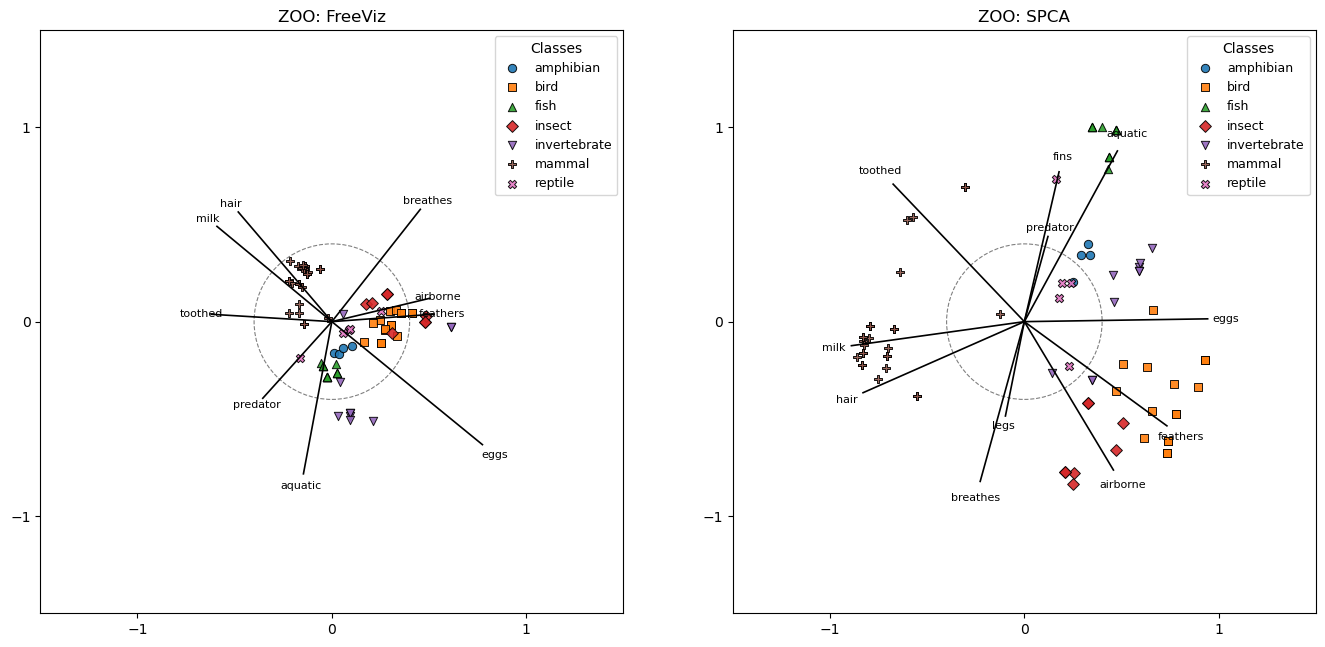

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    P_np, A_np, feature_names, C_np, class_names,
    title='ZOO: FreeViz', ax=ax1, text_scale=1.08
)

plot_projection(
    Z_np, L_np, feature_names, C_np_spca, class_names,
    title='ZOO: SPCA', ax=ax2, text_scale=1.1
)

plt.tight_layout()
plt.show()

# The MUSHROOM dataset

#### Data preparation

In [32]:
E_mush, C_mush, names_mush, feature_names_mush, class_names_mush = load_mushroom_data(device)
E_mush = scale_features(E_mush)

#### Train FreeVIZ

In [33]:
freeviz_mush = Freeviz(E_mush.shape[1]).to(device)
freeviz_mush.train(E_mush, C_mush)

P_mush = freeviz_mush(E_mush)
A_mush = freeviz_mush.A
P_mush_np = P_mush.detach().cpu().numpy()
C_mush_np = C_mush.detach().cpu().numpy()
A_mush_np = A_mush.detach().cpu().numpy()

step: 1 loss: 11156905.0
step: 2 loss: 2272079.75
step: 3 loss: 2261446.25
step: 4 loss: 2273533.5
step: 5 loss: 2274354.5
step: 6 loss: 2257592.5
step: 7 loss: 2247793.75


#### Train SPCA Classification

In [34]:
model_mush = SPCA_Classification(input_dim=E_mush.shape[1], latent_dim=2, num_classes=len(class_names_mush), lr=0.05).to(device)
E_mush_centered = E_mush - E_mush.mean(dim=0)
model_mush.train(E_mush_centered, C_mush, lam=0.01, steps=1000, classifier_epochs=50)

L_mush = model_mush.L.detach().clone()
L_mush = L_mush - L_mush.mean(dim=0, keepdim=True)
loading_norms_mush = torch.norm(L_mush, dim=1)
L_mush = L_mush / loading_norms_mush.max()

Z_mush = E_mush_centered @ L_mush
z_max_mush = torch.abs(Z_mush).max()
Z_mush = Z_mush / z_max_mush

Z_mush_np = Z_mush.cpu().numpy()
C_mush_np_spca = C_mush.cpu().numpy()
L_mush_np = L_mush.cpu().numpy()

Step 0: loss = 77.7041, classifier loss = 0.6466
Step 10: loss = 77.4404, classifier loss = 0.3816
Step 20: loss = 77.3741, classifier loss = 0.3151
Step 30: loss = 77.3543, classifier loss = 0.2944
Step 40: loss = 77.3523, classifier loss = 0.2926
Step 50: loss = 77.3513, classifier loss = 0.2916
Step 60: loss = 77.3504, classifier loss = 0.2907
Step 70: loss = 77.3496, classifier loss = 0.2899
Step 80: loss = 77.3490, classifier loss = 0.2892
Step 90: loss = 77.3484, classifier loss = 0.2886
Step 100: loss = 77.3479, classifier loss = 0.2881
Step 110: loss = 77.3474, classifier loss = 0.2872
Step 120: loss = 77.3469, classifier loss = 0.2869
Step 130: loss = 77.3465, classifier loss = 0.2865
Step 140: loss = 77.3462, classifier loss = 0.2862
Step 150: loss = 77.3460, classifier loss = 0.2859
Step 160: loss = 77.3458, classifier loss = 0.2856
Step 170: loss = 77.3456, classifier loss = 0.2854
Step 180: loss = 77.3454, classifier loss = 0.2852
Step 190: loss = 77.3453, classifier loss 

### Side-by-side comparison

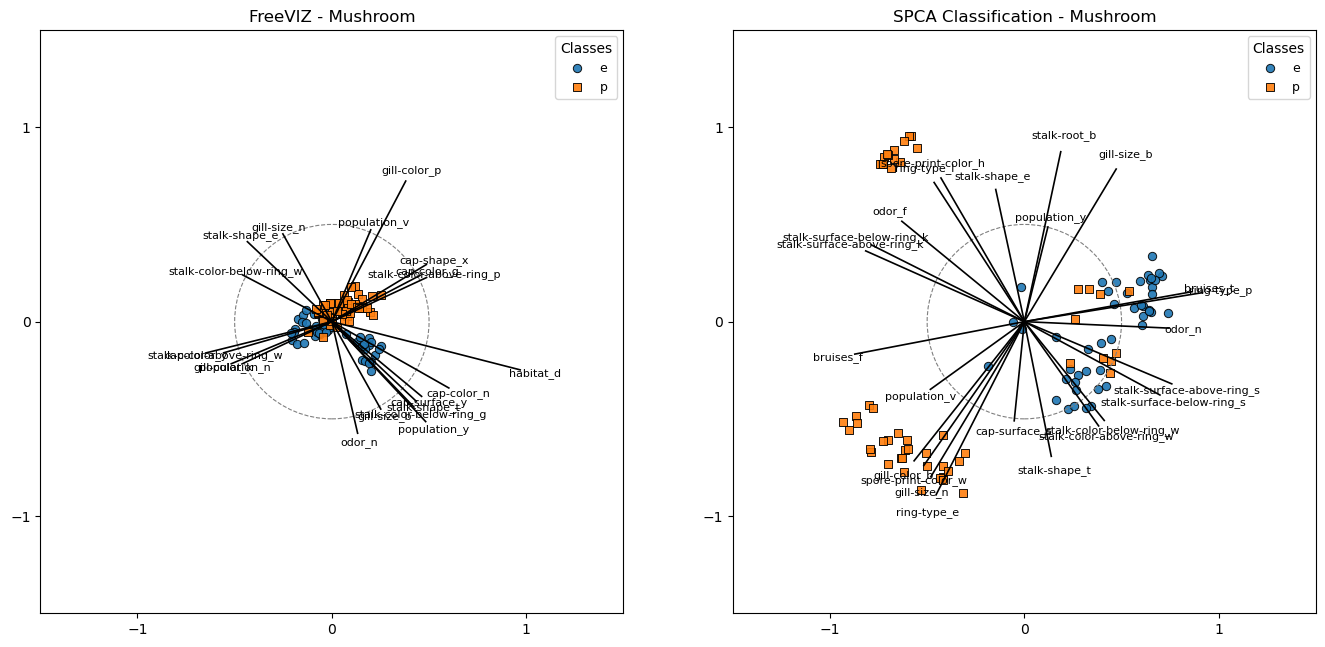

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.5))

plot_projection(
    points=P_mush_np, vectors=A_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np, class_names=class_names_mush,
    title='FreeVIZ - Mushroom', ax=ax1, text_scale=1.08, loading_cutoff=0.5
)

plot_projection(
    points=Z_mush_np, vectors=L_mush_np, feature_names=feature_names_mush,
    class_codes=C_mush_np_spca, class_names=class_names_mush,
    title='SPCA Classification - Mushroom', ax=ax2, text_scale=1.1, loading_cutoff=0.5
)

plt.tight_layout()
plt.show()